# Exploratory Data Analysis 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import re

In [2]:
df = pd.read_csv('../data/raw/manhwa_data_complete.csv')
df.head()


,id,title,score,popularity,genres,tags,main_char,description
0,105398,Solo Leveling,84.0,280633,Action|Adventure|Fantasy,Dungeon:95|Male Protagonist:93|Super Power:92|...,Jin-U Seong,In a world where awakened beings called “Hunte...
1,119257,Omniscient Reader,86.0,128438,Action|Adventure|Fantasy,Survival:97|Post-Apocalyptic:94|Death Game:88|...,Dok-Ja Kim,"Back then, Dok-Ja had no idea. He had no idea ..."
2,85143,Tower of God,82.0,98597,Action|Adventure|Drama|Fantasy|Mystery,Super Power:95|Ensemble Cast:93|Full Color:91|...,Twenty-Fifth Baam,What do you desire? Money and wealth? Honor an...
3,86964,Bastard,83.0,75911,Drama|Horror|Mystery|Psychological|Romance|Thr...,Crime:90|Tragedy:88|Male Protagonist:87|Gore:8...,Jin Seon,"High school life is hard enough, but it’s even..."
4,128067,SSS-Class Revival Hunter,83.0,64902,Action|Adventure|Drama|Fantasy|Supernatural,Time Manipulation:95|Male Protagonist:92|Full ...,Gong-Ja Kim,"In the mysterious, RPG dungeon-like Tower, Con..."


Need to train the recommender system/model from genres, tags, and descriptions. These are the most important features to focus on. Popularity and score will probably skew the model and train it on "what's popular" versus "what's similiar"

In [3]:
# Drop duplicates
df.drop_duplicates(subset='id', inplace=True)
# Set id as the index
df = df.set_index('id')

# Features Cleaning
## Genre Encoding

In [4]:
# Considering dropping or keeping series with no description or tags in a separate pool
no_tags_desc = df[
    (df['tags'].isnull()   | (df['tags'].str.strip()   == '')) &
    (df['description'].isnull() | (df['description'].str.strip() == ''))
]
# Dropping ids with no tags or descriptions for model training
print(f"Before: {len(df)}")
df.drop(no_tags_desc.index, inplace=True)
print(f"After: {len(df)}")
print(f"Rows dropped {len(no_tags_desc)} rows")

Before: 4969
After: 4969
Rows dropped 0 rows


In [5]:
# Genres need to be split to be encoded correctly
genre_dummies = df['genres'].str.get_dummies(sep='|')

In [6]:
# Looking into the data
genre_counts = genre_dummies.sum().sort_values(ascending=False)
genre_counts


Romance          3291
Drama            2606
Fantasy          2257
Action           1138
Comedy            869
Hentai            827
Supernatural      539
Adventure         463
Slice of Life     326
Psychological     266
Mystery           202
Thriller          128
Horror            109
Sci-Fi             94
Sports             57
Ecchi              36
Music              24
Mahou Shoujo        6
Mecha               3
dtype: int64

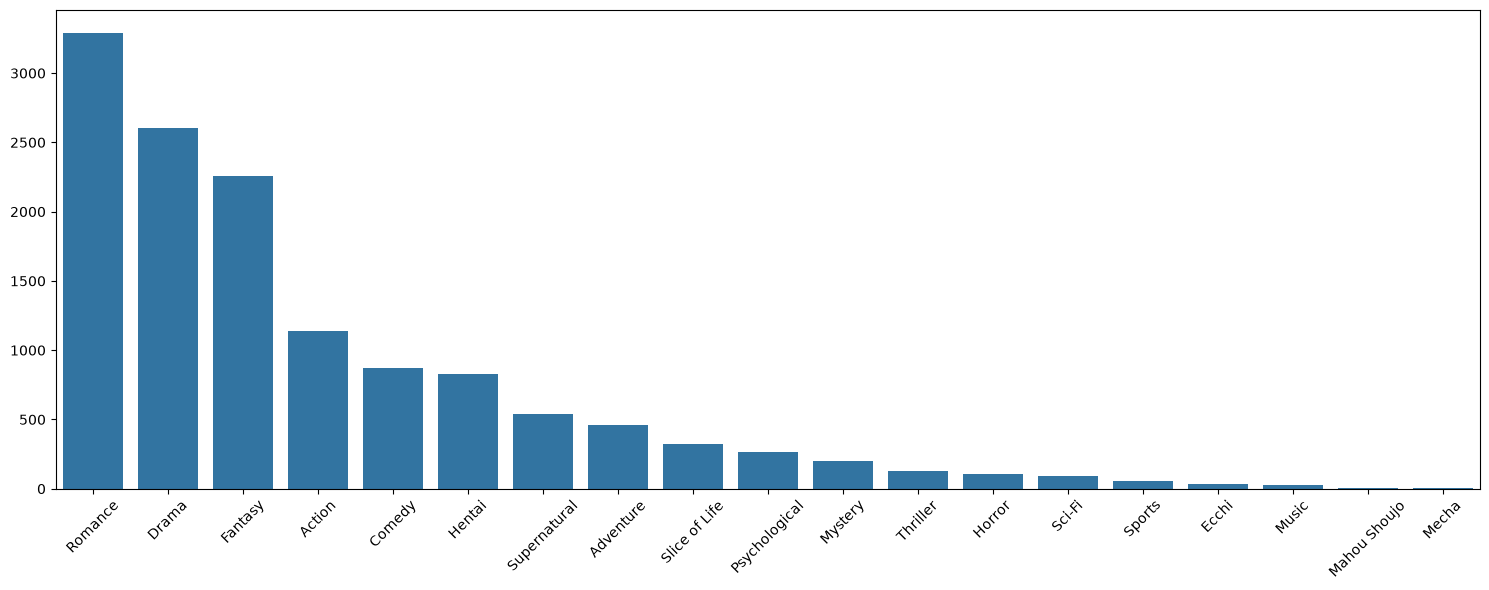

In [7]:
fig, ax = plt.subplots(figsize=(15,6))
ax.tick_params(axis='x', labelrotation=45)
genre_plot = sns.barplot(data=genre_counts, ax=ax)
plt.tight_layout()
plt.show()

In [8]:
# Need to remove genres that are less than 1% of the total; effectively just noise in our data
THRESHOLD = np.floor(len(df) * 0.01)
genres_to_drop = [col for col in genre_dummies if genre_dummies[col].sum() < THRESHOLD]
genre_dummies = genre_dummies.drop(columns=genres_to_drop)
print(f"Dropped {len(genres_to_drop)} rare genres: {genres_to_drop}")

Dropped 4 rare genres: ['Ecchi', 'Mahou Shoujo', 'Mecha', 'Music']


In [9]:
# save vocabulary for interference vectors
joblib.dump(genre_dummies.columns.tolist(), '../artifacts/genre_columns.joblib')

['../artifacts/genre_columns.joblib']

In [10]:
# Putting prefixes so genre columns are identifiable after hstacking with other feature blocks
genre_dummies.columns = [f"genre_{col}" for col in genre_dummies.columns]

In [11]:
# Checking to see if any titles are just are 0 now since that I dropped niche genres
niche_titles_sum = genre_dummies.eq(0).all(axis=1).sum()
print(f"Titles with only niche genres: {niche_titles_sum}")

Titles with only niche genres: 0


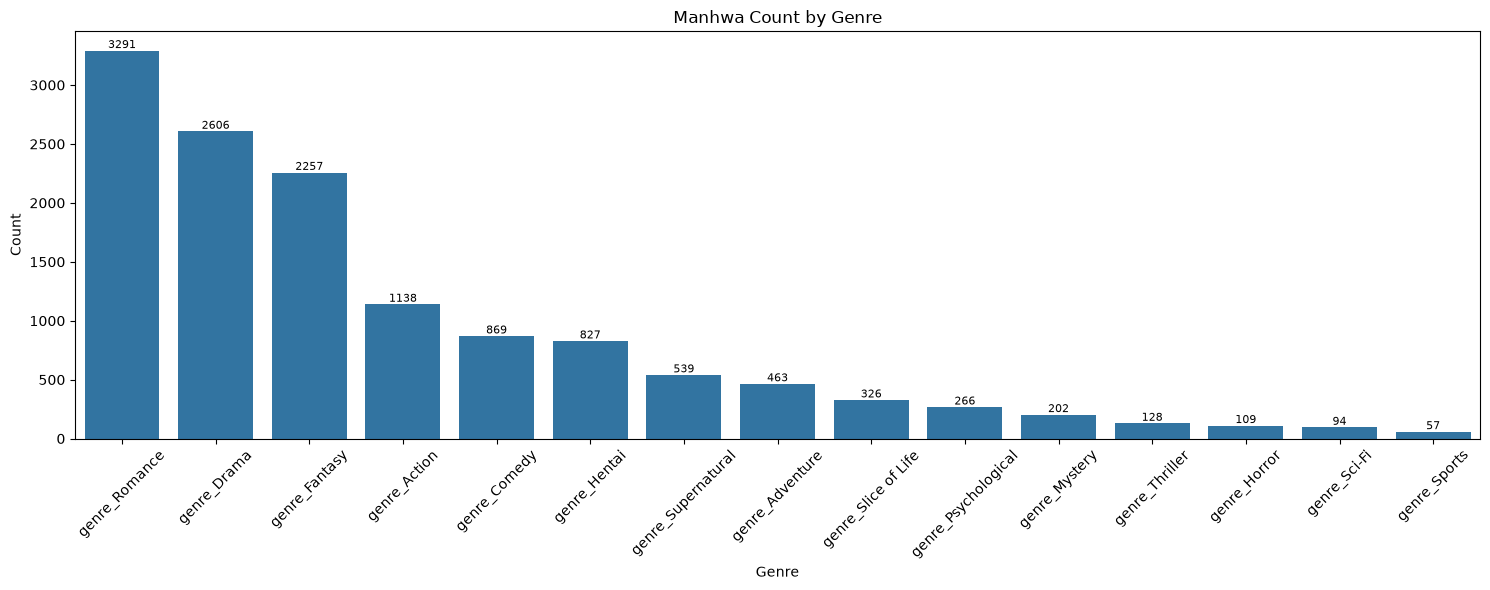

In [12]:
genre_counts = genre_dummies.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=ax)
ax.bar_label(ax.containers[0], fontsize=8)
ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel('Genre')
ax.set_ylabel('Count')
ax.set_title('Manhwa Count by Genre')
plt.tight_layout()
plt.show()

## Tag Parsing

In [13]:
def parse_tag_weights(tags_list: list, min_rank: int = 0) -> dict:
    if not isinstance(tags_list, list):
        return {}  # NaN from str.split on nulls lands here -> all-zero tag vector
    pairs = {}
    for item in tags_list:
        if ':' in item:
            name, rank = item.rsplit(':', 1)
            try:
                rank_int = int(rank)
                if rank_int >= min_rank:                 # tunable cutoff; CSV stores tags unfiltered
                    pairs[name.strip()] = rank_int / 100.0  # Normalize rank to 0-1
            except ValueError:
                pass
    return pairs

In [14]:
# Tags are stored unfiltered in the CSV, so tune this cutoff (0-100 rank
# scale) to explore how tag density trades off against noise.
# 0 = keep every tag; raise it to prune weak/low-rank tags.
TAG_RANK_THRESHOLD = 0

# Parse directly on df — new column, raw tags column preserved
df['tags_dict'] = df['tags'].str.split('|').apply(
    lambda tags: parse_tag_weights(tags, min_rank=TAG_RANK_THRESHOLD)
)

In [15]:
# Audit sparsity — if this is large (>20%), consider down-weighting
# the tag block relative to genres/descriptions in the content matrix
empty_tags = df['tags_dict'].apply(lambda x: len(x) == 0).sum()
print(f"Titles with no tag data: {empty_tags} ({empty_tags/len(df)*100:.1f}%)")

Titles with no tag data: 13 (0.3%)


In [16]:
# Prune tag vocabulary to a 2% document-frequency floor (tags in >= 100 titles).
# Mirrors the genre block's 1% rare-genre drop; tighter here because tags are
# far more numerous (378 unique) and long-tailed.
from collections import Counter

tag_doc_freq = Counter()
for tag_map in df['tags_dict']:
    tag_doc_freq.update(tag_map.keys())

TAG_DF_FLOOR = int(np.floor(len(df) * 0.02))  # 2% of titles = 100
kept_tags = sorted(t for t, n in tag_doc_freq.items() if n >= TAG_DF_FLOOR)
dropped = len(tag_doc_freq) - len(kept_tags)
print(f"Kept {len(kept_tags)} tags (>= {TAG_DF_FLOOR} titles); dropped {dropped} rare tags")

Kept 97 tags (>= 99 titles); dropped 281 rare tags


In [17]:
# Expand tags_dict (list of {name: weight} dicts) into a dense weighted matrix.
# Missing tags -> 0.0; present tags keep their normalized rank weight (0-1).
# Subset to the kept vocabulary; sorted kept_tags gives deterministic column order.
tag_weights = pd.DataFrame(df['tags_dict'].tolist(), index=df.index).fillna(0.0)
tag_weights = tag_weights[kept_tags]

In [18]:
# Save vocabulary for building inference vectors (raw names, prefix applied later)
joblib.dump(tag_weights.columns.tolist(), '../artifacts/tag_columns.joblib')

['../artifacts/tag_columns.joblib']

In [19]:
# Prefix so tag columns stay identifiable after hstacking with other feature blocks
tag_weights.columns = [f"tag_{col}" for col in tag_weights.columns]